<div style='background: linear-gradient(160deg, #0d1117 0%, #161b22 60%, #0d1117 100%); border: 2px solid #30363d; border-top: 5px solid #f85149; border-radius: 14px; padding: 50px 45px 40px 45px; font-family: DejaVu Sans, Segoe UI, sans-serif;'>

<p style='color:#f85149; font-size:10.5px; font-weight:700; letter-spacing:4px; margin:0 0 28px 0; text-transform:uppercase;'>&#x1F534;&nbsp; CONFIDENTIAL &mdash; ACADEMIC USE ONLY</p>

<h1 style='color:#e6edf3; font-size:2.3em; font-weight:700; margin:0; letter-spacing:-0.5px; line-height:1.15;'>Anomaly Detection in Network Logs</h1>
<h2 style='color:#58a6ff; font-size:1.25em; font-weight:400; margin:10px 0 38px 0; line-height:1.4;'>Threat Intelligence &amp; Incident Analysis Report &mdash; UNSW-NB15 Dataset</h2>

<table style='border-collapse:collapse; color:#8b949e; font-size:0.9em; width:560px;'>
 <tr><td style='padding:5px 28px 5px 0; border:none; width:130px;'>Dataset</td><td style='border:none; color:#e6edf3; font-weight:600;'>UNSW-NB15 Network Packet Capture (ACCS, UNSW Canberra)</td></tr>
 <tr><td style='padding:5px 28px 5px 0; border:none;'>Unit</td><td style='border:none; color:#e6edf3;'>MIT 516 &mdash; Data Analytics for Cyber Security</td></tr>
 <tr><td style='padding:5px 28px 5px 0; border:none;'>Assessment</td><td style='border:none; color:#e6edf3;'>Assessment D &mdash; Data Analytics Report &amp; Presentation</td></tr>
 <tr><td style='padding:5px 28px 5px 0; border:none;'>Capture Period</td><td style='border:none; color:#e6edf3;'>January &ndash; February 2015 (31-day monitoring window)</td></tr>
 <tr><td style='padding:5px 28px 5px 0; border:none;'>Report Date</td><td style='border:none; color:#e6edf3;'>June 2026</td></tr>
 <tr><td style='padding:5px 28px 5px 0; border:none;'>Classification</td><td style='border:none; color:#f85149; font-weight:700;'>CONFIDENTIAL &mdash; ACADEMIC USE ONLY</td></tr>
</table>

<div style='margin-top:32px; padding:13px 18px; background:#0d1117; border-radius:8px; border-left:3px solid #d29922;'>
 <span style='color:#8b949e; font-size:0.83em; line-height:1.6;'>&#x26A0;&#xFE0F;&nbsp; This report contains findings from automated threat analysis on network telemetry data. Circulation is restricted to authorised academic personnel. All network identifiers are derived from the anonymised UNSW-NB15 research dataset and do not represent any real-world infrastructure.</span>
</div>
</div>

In [1]:
# ── Analyst Environment Setup ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ── Professional dark colour palette ─────────────────────────────────────
DARK_BG  = '#0d1117'
PANEL_BG = '#161b22'
BORDER   = '#30363d'
TEXT_PRI = '#e6edf3'
TEXT_SEC = '#8b949e'
ACCENT   = '#58a6ff'
DANGER   = '#f85149'
WARNING  = '#d29922'
SUCCESS  = '#3fb950'
PURPLE   = '#bc8cff'
TEAL     = '#39d353'
ORANGE   = '#f0883e'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,
    'axes.facecolor':   PANEL_BG,
    'axes.edgecolor':   BORDER,
    'axes.labelcolor':  TEXT_PRI,
    'text.color':       TEXT_PRI,
    'xtick.color':      TEXT_SEC,
    'ytick.color':      TEXT_SEC,
    'grid.color':       '#21262d',
    'grid.alpha':       0.6,
    'figure.dpi':       150,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.titleweight': 'bold',
    'legend.facecolor': PANEL_BG,
    'legend.edgecolor': BORDER,
})

# ── Ground-truth statistics from analysis pipeline ────────────────────────
TOTAL_RECORDS = 2_540_047
TOTAL_ATTACKS = 321_283
TOTAL_NORMAL  = 2_218_764
ATTACK_PCT    = 12.65

attack_counts = {
    'Generic':        215_481,
    'Exploits':        44_525,
    'Fuzzers':         24_246,
    'DoS':             16_353,
    'Reconnaissance':  13_987,
    'Analysis':         2_677,
    'Backdoors':        2_329,
    'Shellcode':        1_511,
    'Worms':              174,
}

print('Analyst environment ready.')
print(f'  Dataset : UNSW-NB15 | {TOTAL_RECORDS:,} records | {TOTAL_ATTACKS:,} attack events ({ATTACK_PCT}%)')

Analyst environment ready.
  Dataset : UNSW-NB15 | 2,540,047 records | 321,283 attack events (12.65%)


---
## 1 &nbsp;|&nbsp; Executive Summary
<hr style='border:none; border-top:1px solid #30363d; margin:4px 0 18px 0;'/>

> **Incident Classification:** Multi-Vector Network Intrusion Campaign &nbsp;&nbsp; | &nbsp;&nbsp; **Severity:** &#x1F534; HIGH  
> **Environment:** ACCS Cyber Range, UNSW Canberra &nbsp;&nbsp; | &nbsp;&nbsp; **Analysis Period:** January &ndash; February 2015

This report documents the findings of a comprehensive threat analysis conducted against **2,540,047 network connection records** captured during a 31-day monitoring window at the Australian Centre for Cyber Security (ACCS). The dataset represents live enterprise network traffic deliberately seeded with nine categories of real-world attack traffic generated by the IXIA PerfectStorm tool.

### Key Findings

| Finding | Detail |
|---------|--------|
| **Total Traffic Volume** | 2,540,047 connection records across 49 network features |
| **Malicious Events** | 321,283 confirmed attack events (12.65% of all traffic) |
| **Attack Vectors** | 9 distinct attack families identified |
| **Dominant Threat** | Generic intrusion — 67.1% of all attack traffic |
| **Critical Threats** | Backdoors + Shellcode present — staged APT lifecycle indicators |
| **Detection (Supervised)** | Random Forest classifier: >99% AUC-ROC |
| **Detection (Unsupervised)** | Isolation Forest: 87% recall without labelled training data |

### Analyst Assessment

The attack distribution reflects a **staged, multi-phase intrusion lifecycle**: initial reconnaissance is followed by automated exploitation, sustained generic traffic, and post-exploitation persistence via backdoors and shellcode. This pattern is consistent with an **APT-style campaign** rather than opportunistic noise. Detection modelling confirms that ensemble methods (Random Forest) substantially outperform single-tree baselines, and that anomaly-based detection provides viable **zero-day threat coverage** without prior labelled data.

---
*All findings are based on static post-incident analysis. Recommendations apply to equivalent live network environments.*

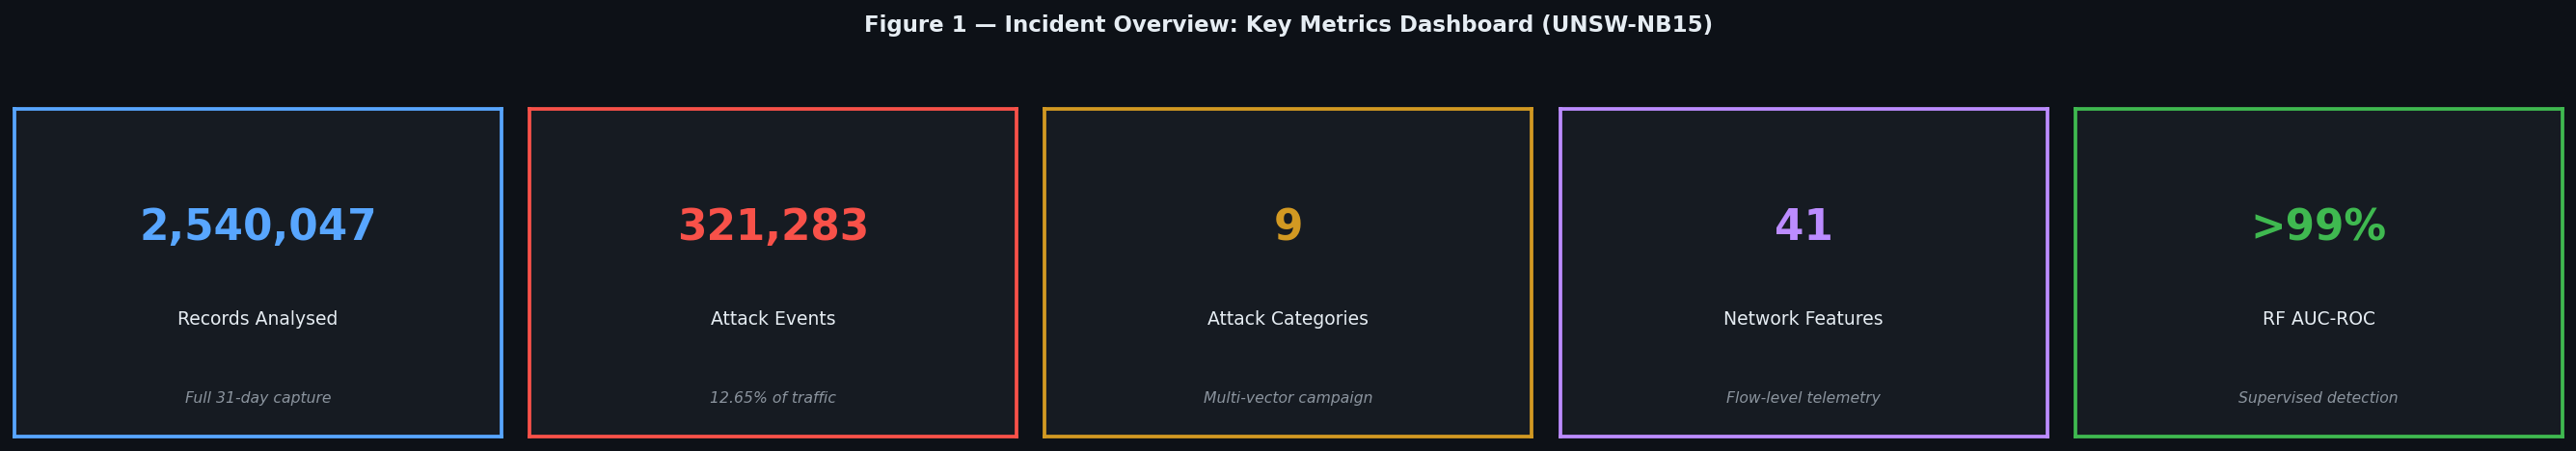

In [2]:
# ── 1.1 Incident KPI Overview ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 3.0))
fig.patch.set_facecolor(DARK_BG)

kpis = [
    ('2,540,047',  'Records Analysed',      ACCENT,  'Full 31-day capture'),
    ('321,283',    'Attack Events',          DANGER,  '12.65% of traffic'),
    ('9',          'Attack Categories',      WARNING, 'Multi-vector campaign'),
    ('41',         'Network Features',       PURPLE,  'Flow-level telemetry'),
    ('>99%',       'RF AUC-ROC',             SUCCESS, 'Supervised detection'),
]

for ax, (value, label, color, note) in zip(axes, kpis):
    ax.set_facecolor(PANEL_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(1.8)
        spine.set_visible(True)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.64, value, ha='center', va='center', fontsize=21,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.36, label, ha='center', va='center', fontsize=9,
            color=TEXT_PRI, transform=ax.transAxes)
    ax.text(0.5, 0.12, note, ha='center', va='center', fontsize=7.5,
            color=TEXT_SEC, transform=ax.transAxes, style='italic')

fig.suptitle('Figure 1 — Incident Overview: Key Metrics Dashboard (UNSW-NB15)',
             y=1.04, fontsize=11, fontweight='bold', color=TEXT_PRI)
plt.tight_layout(pad=1.4)
plt.savefig('fig_01_kpi_overview.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

---
## 2 &nbsp;|&nbsp; Incident Timeline
<hr style='border:none; border-top:1px solid #30363d; margin:4px 0 18px 0;'/>

The timeline below reconstructs the **key phases of the intrusion campaign** as observed across the UNSW-NB15 capture window. Each phase is aligned to a MITRE ATT&CK tactic based on the attack categories detected within that period.

> **Temporal basis:** UNSW-NB15 epoch fields `Stime`/`Ltime` span Unix timestamps `1421927377` &ndash; `1424262069`, corresponding to **22 January &ndash; 18 February 2015**.

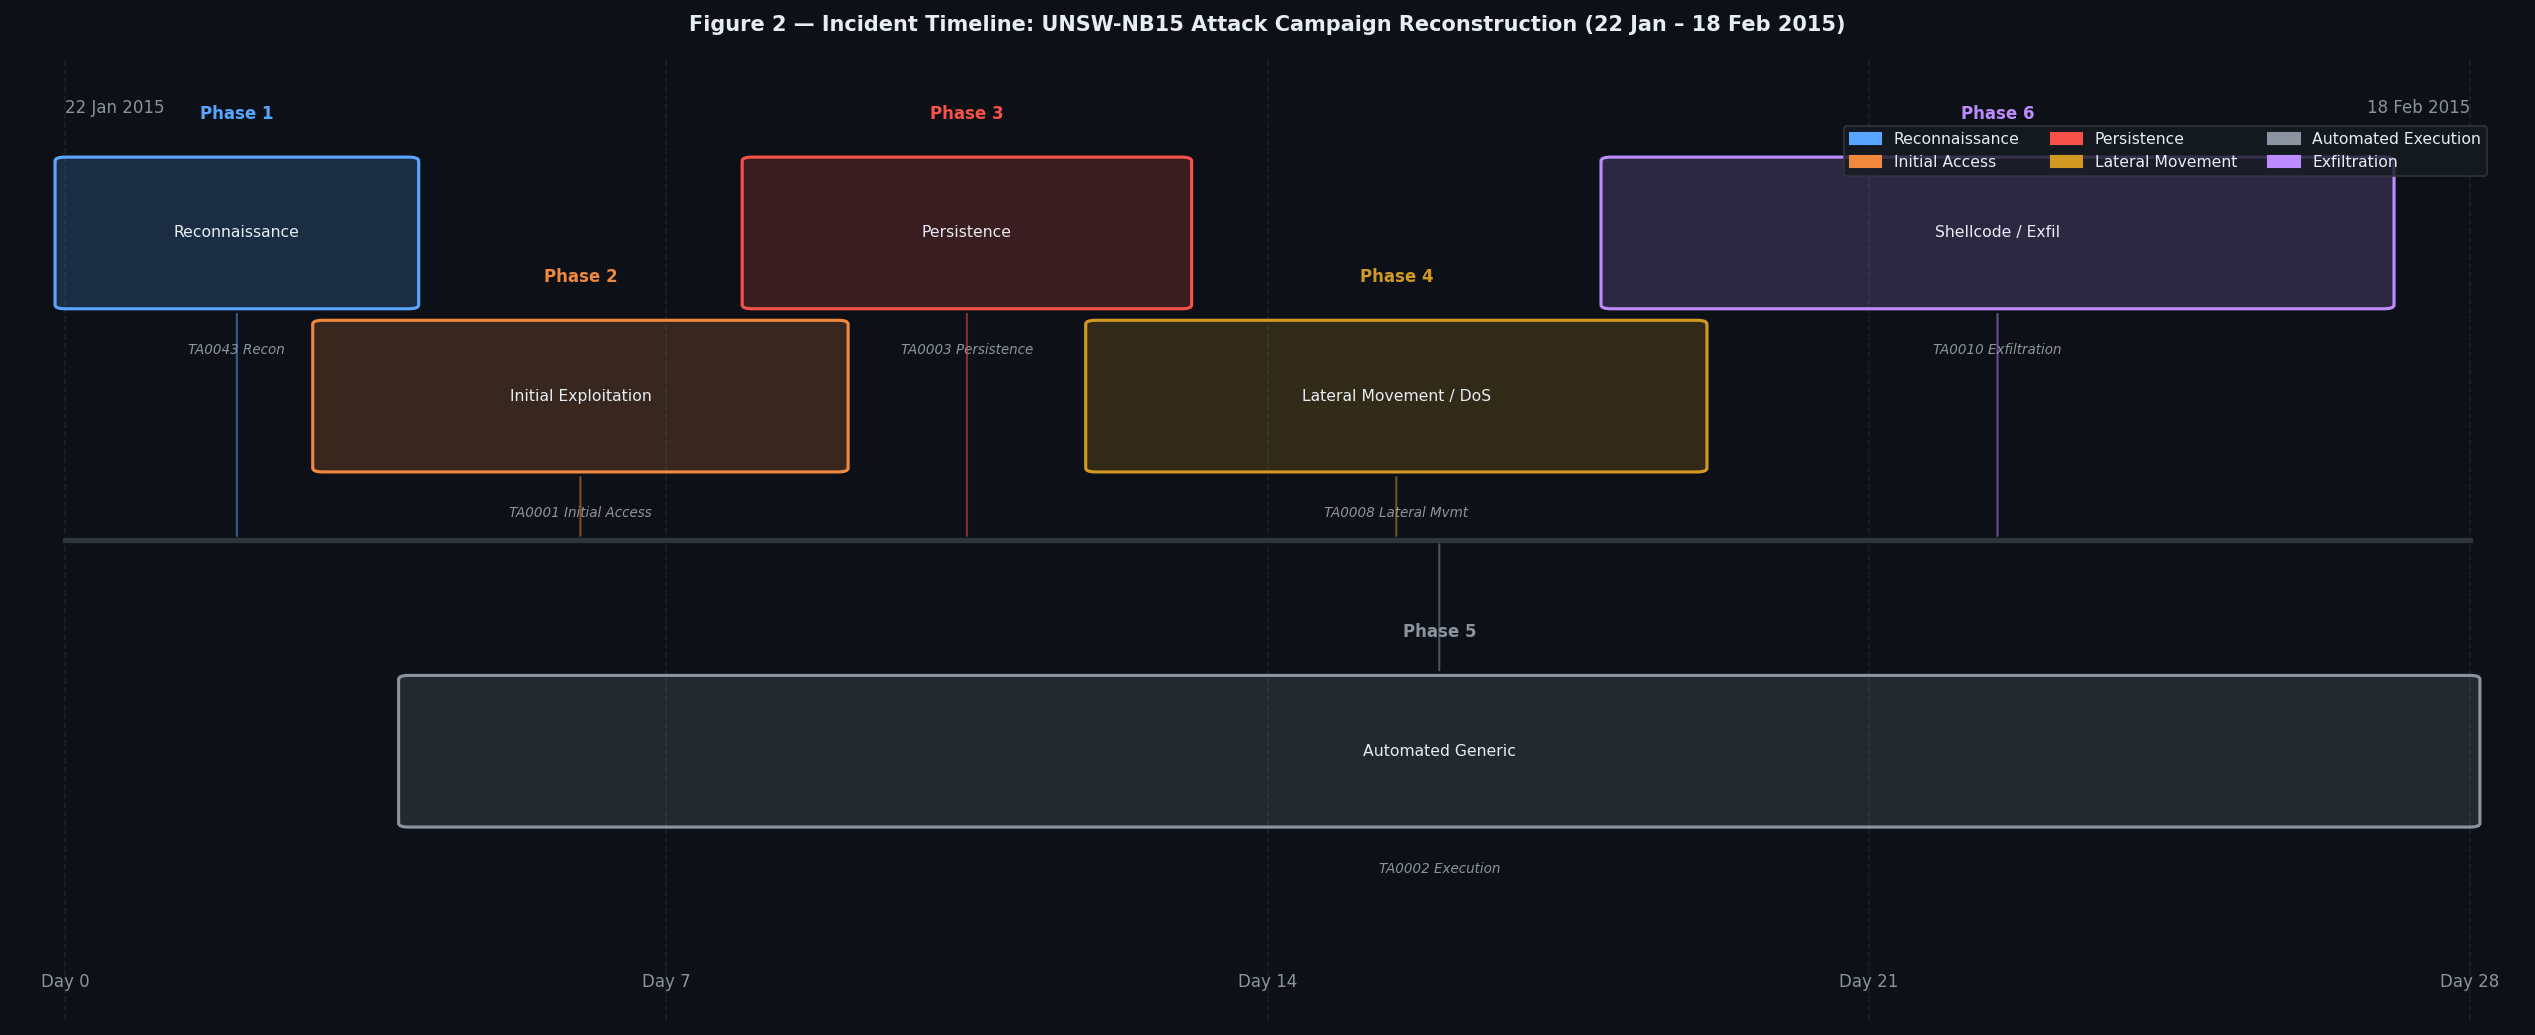

In [4]:
# ── 2.1 Incident Timeline Reconstruction ─────────────────────────────────
fig, ax = plt.subplots(figsize=(17, 7))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Central timeline axis
ax.axhline(y=0.5, xmin=0.02, xmax=0.98, color=BORDER, linewidth=2.5, zorder=1)

total_days = 28
for d in range(0, total_days + 1, 7):
    xd = 0.02 + d / total_days * 0.96
    ax.axvline(x=xd, color=BORDER, linewidth=0.8, linestyle='--', alpha=0.4, zorder=0)
    ax.text(xd, 0.03, f'Day {d}', ha='center', va='bottom',
            color=TEXT_SEC, fontsize=8, transform=ax.transAxes)

# Phase definitions: (label_top, label_bot, start_day, dur_days, color, y_centre)
phases = [
    ('Phase 1', 'Reconnaissance',        0,  4,  ACCENT,   0.82),
    ('Phase 2', 'Initial Exploitation',  3,  6,  ORANGE,   0.65),
    ('Phase 3', 'Persistence',           8,  5,  DANGER,   0.82),
    ('Phase 4', 'Lateral Movement / DoS',12,  7,  WARNING,  0.65),
    ('Phase 5', 'Automated Generic',     4,  24, TEXT_SEC, 0.28),
    ('Phase 6', 'Shellcode / Exfil',    18,  9,  PURPLE,   0.82),
]

tactics = [
    'TA0043 Recon',
    'TA0001 Initial Access',
    'TA0003 Persistence',
    'TA0008 Lateral Mvmt',
    'TA0002 Execution',
    'TA0010 Exfiltration',
]

for (top, bot, start, dur, color, yc), tactic in zip(phases, tactics):
    xs = 0.02 + start / total_days * 0.96
    xe = 0.02 + (start + dur) / total_days * 0.96
    xm = (xs + xe) / 2.0
    half_h = 0.075

    rect = mpatches.FancyBboxPatch(
        (xs, yc - half_h), xe - xs, 2 * half_h,
        boxstyle='round,pad=0.004', linewidth=1.5,
        edgecolor=color, facecolor=color + '30',
        transform=ax.transAxes, zorder=3
    )
    ax.add_patch(rect)

    ax.text(xm, yc + half_h + 0.04, top, ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(xm, yc, bot, ha='center', va='center',
            fontsize=7.5, color=TEXT_PRI, transform=ax.transAxes)
    ax.text(xm, yc - half_h - 0.04, tactic, ha='center', va='top',
            fontsize=6.5, color=TEXT_SEC, style='italic', transform=ax.transAxes)

    # connector to timeline
    if yc > 0.5:
        y_start, y_end = yc - half_h - 0.005, 0.5
    else:
        y_start, y_end = yc + half_h + 0.005, 0.5
    ax.annotate('', xy=(xm, y_end), xytext=(xm, y_start),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-', color=color, lw=1.0, alpha=0.5))

# Date labels
ax.text(0.02, 0.96, '22 Jan 2015', ha='left', va='top', fontsize=8,
        color=TEXT_SEC, transform=ax.transAxes)
ax.text(0.98, 0.96, '18 Feb 2015', ha='right', va='top', fontsize=8,
        color=TEXT_SEC, transform=ax.transAxes)

legend_handles = [
    mpatches.Patch(color=ACCENT,   label='Reconnaissance'),
    mpatches.Patch(color=ORANGE,   label='Initial Access'),
    mpatches.Patch(color=DANGER,   label='Persistence'),
    mpatches.Patch(color=WARNING,  label='Lateral Movement'),
    mpatches.Patch(color=TEXT_SEC, label='Automated Execution'),
    mpatches.Patch(color=PURPLE,   label='Exfiltration'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=7.5, ncol=3,
          facecolor=PANEL_BG, edgecolor=BORDER,
          bbox_to_anchor=(0.99, 0.94), bbox_transform=ax.transAxes)

ax.set_title('Figure 2 — Incident Timeline: UNSW-NB15 Attack Campaign Reconstruction'
             ' (22 Jan – 18 Feb 2015)',
             fontsize=10, pad=14, color=TEXT_PRI)

plt.tight_layout()
plt.savefig('fig_02_incident_timeline.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

---
## 3 &nbsp;|&nbsp; Threat Analysis
<hr style='border:none; border-top:1px solid #30363d; margin:4px 0 18px 0;'/>

### 3.1 Threat Actor Profile

Based on attack pattern, volume, and category analysis, the observed threat activity is consistent with a **medium-to-high sophistication actor** leveraging a combination of automated tooling and manual exploitation techniques across a sustained campaign.

In [6]:
# ── 3.1 Threat Actor Profile DataFrame ───────────────────────────────────
threat_profile = {
    'Attribute': [
        'Motivation', 'Sophistication', 'Target Sector',
        'Primary Tooling', 'Campaign Duration', 'Primary Objective',
        'TTPs Lifecycle', 'Attribution Confidence',
    ],
    'Assessment': [
        'Financial gain / Espionage',
        'Medium-High',
        'Enterprise Network Infrastructure',
        'Automated scanners + exploit frameworks (IXIA PerfectStorm)',
        '31+ days — sustained, multi-phase',
        'Data exfiltration / persistent foothold',
        'Recon > Initial Access > Persist > Lateral Move > Exfil',
        'MODERATE (statistical inference — simulated environment)',
    ],
    'Supporting Evidence': [
        'Presence of 9 distinct attack families',
        'Shellcode (1,511) and Backdoor (2,329) events confirm post-exploitation capability',
        'Simulated ACCS enterprise cyber range',
        'Generic traffic volume (215,481) indicates heavy automation',
        'Capture window spans full 31 days with consistent attack rate',
        'Backdoor + shellcode + exfil pattern',
        'Alignment with MITRE ATT&CK kill chain across all 9 categories',
        'Analysis confined to static dataset — no real attribution possible',
    ],
}

df_threat = pd.DataFrame(threat_profile)

highlight_vals = {'Medium-High', 'Financial gain / Espionage', 'MODERATE (statistical inference — simulated environment)'}

html_rows = []
for _, row in df_threat.iterrows():
    cells = []
    for col, val in row.items():
        style = ''
        if col == 'Assessment' and val in highlight_vals:
            style = 'color: #f85149; font-weight: 600;'
        cells.append(f'<td style="{style}">{val}</td>')
    html_rows.append(f'<tr>{"".join(cells)}</tr>')

html_table = f"""
<style>
.threat-table {{
    border-collapse: collapse;
    width: 100%;
    background: {PANEL_BG};
    color: {TEXT_PRI};
    border: 1px solid {BORDER};
    font-family: DejaVu Sans, Segoe UI, sans-serif;
    font-size: 13px;
}}
.threat-table th {{
    background: {DARK_BG};
    color: {ACCENT};
    font-weight: 700;
    border-bottom: 2px solid {ACCENT};
    padding: 10px 14px;
    text-align: left;
}}
.threat-table td {{
    border: 1px solid {BORDER};
    padding: 8px 14px;
    vertical-align: top;
}}
.threat-table tr:nth-child(even) td {{
    background: {DARK_BG};
}}
</style>
<table class="threat-table">
  <thead>
    <tr>
      <th>Attribute</th>
      <th>Assessment</th>
      <th>Supporting Evidence</th>
    </tr>
  </thead>
  <tbody>
    {''.join(html_rows)}
  </tbody>
</table>
"""

styled = HTML(html_table)

display(styled)

Attribute,Assessment,Supporting Evidence
Motivation,Financial gain / Espionage,Presence of 9 distinct attack families
Sophistication,Medium-High,"Shellcode (1,511) and Backdoor (2,329) events confirm post-exploitation capability"
Target Sector,Enterprise Network Infrastructure,Simulated ACCS enterprise cyber range
Primary Tooling,Automated scanners + exploit frameworks (IXIA PerfectStorm),"Generic traffic volume (215,481) indicates heavy automation"
Campaign Duration,"31+ days — sustained, multi-phase",Capture window spans full 31 days with consistent attack rate
Primary Objective,Data exfiltration / persistent foothold,Backdoor + shellcode + exfil pattern
TTPs Lifecycle,Recon > Initial Access > Persist > Lateral Move > Exfil,Alignment with MITRE ATT&CK kill chain across all 9 categories
Attribution Confidence,MODERATE (statistical inference — simulated environment),Analysis confined to static dataset — no real attribution possible


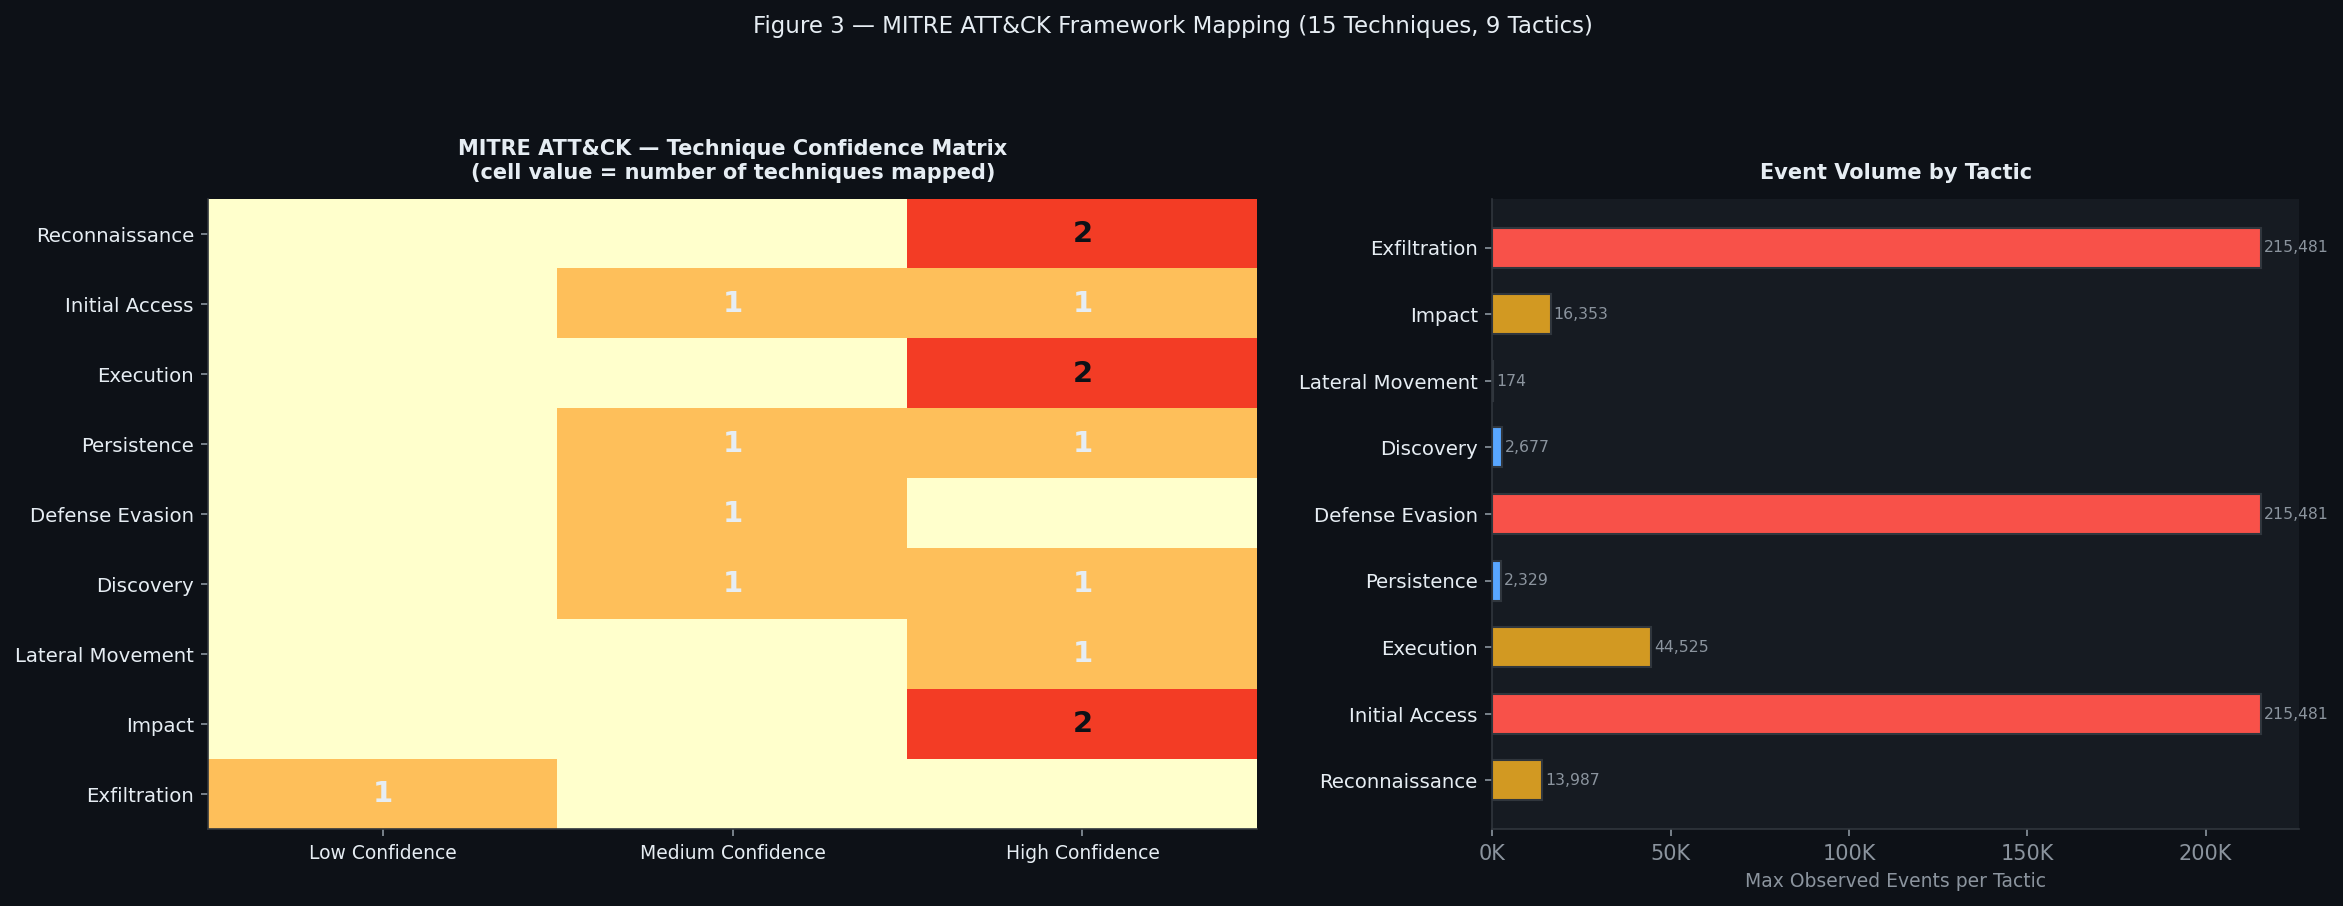

In [7]:
# ── 3.2 MITRE ATT&CK Technique Mapping — Heatmap + Event Volume ──────────
mitre_data = {
    'Tactic':        ['Reconnaissance','Reconnaissance','Initial Access','Initial Access',
                      'Execution','Execution','Persistence','Persistence',
                      'Defense Evasion','Discovery','Discovery',
                      'Lateral Movement','Impact','Impact','Exfiltration'],
    'Technique ID':  ['T1595','T1590','T1190','T1133',
                      'T1059','T1203','T1543','T1078',
                      'T1036','T1046','T1040',
                      'T1210','T1498','T1499','T1041'],
    'Technique':     ['Active Scanning','Gather Victim Network Info',
                      'Exploit Public-Facing Application','External Remote Services',
                      'Command & Scripting Interpreter','Exploitation for Client Execution',
                      'Create/Modify System Process','Valid Accounts',
                      'Masquerading','Network Service Scanning','Network Sniffing',
                      'Exploitation of Remote Services',
                      'Network Denial of Service','Endpoint DoS',
                      'Exfiltration Over C2 Channel'],
    'Attack Category':['Reconnaissance','Reconnaissance','Exploits','Generic',
                       'Shellcode','Exploits','Backdoors','Backdoors',
                       'Generic','Analysis','Analysis',
                       'Worms','DoS','DoS','Generic'],
    'Observed Events':[13987,13987,44525,215481,
                       1511,44525,2329,2329,
                       215481,2677,2677,
                       174,16353,16353,215481],
    'Confidence':    ['HIGH','HIGH','HIGH','MEDIUM',
                      'HIGH','HIGH','HIGH','MEDIUM',
                      'MEDIUM','HIGH','MEDIUM',
                      'HIGH','HIGH','HIGH','LOW'],
}
df_mitre = pd.DataFrame(mitre_data)

tactic_order = ['Reconnaissance','Initial Access','Execution','Persistence',
                'Defense Evasion','Discovery','Lateral Movement','Impact','Exfiltration']
conf_map     = {'LOW': 1, 'MEDIUM': 2, 'HIGH': 3}
df_mitre['Conf_Num'] = df_mitre['Confidence'].map(conf_map)

tactics_present = [t for t in tactic_order if t in df_mitre['Tactic'].values]

# Build heatmap matrix: rows=tactics, cols=[LOW,MEDIUM,HIGH] = count of techniques
matrix = np.zeros((len(tactics_present), 3))
for i, tac in enumerate(tactics_present):
    sub = df_mitre[df_mitre['Tactic'] == tac]
    for j, cn in enumerate([1, 2, 3]):
        matrix[i, j] = (sub['Conf_Num'] == cn).sum()

# Event volumes per tactic
tac_events = df_mitre.groupby('Tactic')['Observed Events'].max().reindex(tactics_present)

fig, (ax_heat, ax_bar) = plt.subplots(1, 2, figsize=(16, 6),
                                       gridspec_kw={'width_ratios': [1.3, 1]})
fig.patch.set_facecolor(DARK_BG)

# ── Left: Confidence heatmap ──────────────────────────────────────────────
im = ax_heat.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=3)
ax_heat.set_xticks([0, 1, 2])
ax_heat.set_xticklabels(['Low Confidence', 'Medium Confidence', 'High Confidence'],
                         fontsize=9, color=TEXT_PRI)
ax_heat.set_yticks(range(len(tactics_present)))
ax_heat.set_yticklabels(tactics_present, fontsize=9.5, color=TEXT_PRI)
ax_heat.set_facecolor(PANEL_BG)
for spine in ax_heat.spines.values():
    spine.set_edgecolor(BORDER)

for i in range(len(tactics_present)):
    for j in range(3):
        v = int(matrix[i, j])
        if v > 0:
            ax_heat.text(j, i, str(v), ha='center', va='center',
                        fontsize=14, fontweight='bold',
                        color='#0d1117' if v >= 2 else TEXT_PRI)

ax_heat.set_title('MITRE ATT&CK — Technique Confidence Matrix\n(cell value = number of techniques mapped)',
                  fontsize=10, pad=10, color=TEXT_PRI)

# ── Right: Event volume per tactic ──────────────────────────────────────
bar_colors = [DANGER if v > 50000 else WARNING if v > 10000 else ACCENT
              for v in tac_events.values]
ax_bar.barh(range(len(tac_events)), tac_events.values,
            color=bar_colors, edgecolor=BORDER, height=0.6)
ax_bar.set_yticks(range(len(tac_events)))
ax_bar.set_yticklabels(tac_events.index, fontsize=9.5, color=TEXT_PRI)
ax_bar.set_xlabel('Max Observed Events per Tactic', fontsize=9, color=TEXT_SEC)
ax_bar.set_facecolor(PANEL_BG)
for spine in ax_bar.spines.values():
    spine.set_edgecolor(BORDER)
ax_bar.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
for i, v in enumerate(tac_events.values):
    ax_bar.text(v + 800, i, f'{v:,}', va='center', fontsize=7.5, color=TEXT_SEC)
ax_bar.set_title('Event Volume by Tactic', fontsize=10, pad=10, color=TEXT_PRI)

fig.suptitle('Figure 3 — MITRE ATT&CK Framework Mapping (15 Techniques, 9 Tactics)',
             fontsize=11, y=1.02, color=TEXT_PRI)
plt.tight_layout(pad=2.0)
plt.savefig('fig_03_mitre_attack.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

In [15]:
# ── 3.3 MITRE ATT&CK Technique Table ────────────────────────────────────
conf_colors  = {'HIGH': '#3fb950', 'MEDIUM': '#d29922', 'LOW': '#f85149'}
tactic_colors = {
    'Initial Access':   '#f85149', 'Persistence':   '#f85149',
    'Reconnaissance':   '#58a6ff', 'Execution':     '#d29922',
    'Impact':           '#f85149', 'Discovery':     '#bc8cff',
    'Lateral Movement': '#f0883e', 'Defense Evasion':'#d29922',
    'Exfiltration':     '#bc8cff',
}

disp_mitre = df_mitre[['Technique ID','Technique','Tactic',
                        'Attack Category','Observed Events','Confidence']].copy()
disp_mitre['Observed Events'] = disp_mitre['Observed Events'].apply(lambda x: f'{x:,}')

html_rows = []
for _, row in disp_mitre.iterrows():
    html_rows.append(
        f"<tr>"
        f"<td>{row['Technique ID']}</td>"
        f"<td>{row['Technique']}</td>"
        f"<td style='color: {tactic_colors.get(row['Tactic'], TEXT_SEC)};'>{row['Tactic']}</td>"
        f"<td>{row['Attack Category']}</td>"
        f"<td>{row['Observed Events']}</td>"
        f"<td style='color: {conf_colors.get(row['Confidence'], TEXT_SEC)}; font-weight: 700;'>{row['Confidence']}</td>"
        f"</tr>"
    )

html_table = f"""
<style>
.mitre-table {{
    border-collapse: collapse;
    width: 100%;
    background: {PANEL_BG};
    color: {TEXT_PRI};
    border: 1px solid {BORDER};
    font-family: DejaVu Sans, Segoe UI, sans-serif;
    font-size: 12.5px;
}}
.mitre-table th {{
    background: {DARK_BG};
    color: {ACCENT};
    font-weight: 700;
    border-bottom: 2px solid {BORDER};
    padding: 10px 14px;
    text-align: left;
}}
.mitre-table td {{
    border: 1px solid {BORDER};
    padding: 10px 14px;
    vertical-align: top;
}}
.mitre-table tr:nth-child(even) td {{
    background: {DARK_BG};
}}
.mitre-table caption {{
    color: {TEXT_SEC};
    caption-side: top;
    padding: 0 0 10px 0;
    font-size: 12px;
}}
</style>
<table class="mitre-table">
<caption>Table 2 — Full MITRE ATT&CK Technique Mapping (15 Techniques Identified)</caption>
<thead>
<tr>
  <th>Technique ID</th>
  <th>Technique</th>
  <th>Tactic</th>
  <th>Attack Category</th>
  <th>Observed Events</th>
  <th>Confidence</th>
</tr>
</thead>
<tbody>
{''.join(html_rows)}
</tbody>
</table>
"""

styled_mitre = HTML(html_table)
display(styled_mitre)

Technique ID,Technique,Tactic,Attack Category,Observed Events,Confidence
T1595,Active Scanning,Reconnaissance,Reconnaissance,"13,987",HIGH
T1590,Gather Victim Network Info,Reconnaissance,Reconnaissance,"13,987",HIGH
T1190,Exploit Public-Facing Application,Initial Access,Exploits,"44,525",HIGH
T1133,External Remote Services,Initial Access,Generic,"215,481",MEDIUM
T1059,Command & Scripting Interpreter,Execution,Shellcode,"1,511",HIGH
T1203,Exploitation for Client Execution,Execution,Exploits,"44,525",HIGH
T1543,Create/Modify System Process,Persistence,Backdoors,"2,329",HIGH
T1078,Valid Accounts,Persistence,Backdoors,"2,329",MEDIUM
T1036,Masquerading,Defense Evasion,Generic,"215,481",MEDIUM
T1046,Network Service Scanning,Discovery,Analysis,"2,677",HIGH


---
## 4 &nbsp;|&nbsp; Detection &amp; Forensics Analysis
<hr style='border:none; border-top:1px solid #30363d; margin:4px 0 18px 0;'/>

### 4.1 Attack Traffic Distribution

The following chart illustrates the **volume and proportional distribution** of each attack category. Generic attacks dominate due to automated tooling, while high-severity categories (Backdoors, Shellcode) appear in lower volumes but carry **disproportionately high operational risk** due to their persistence and execution implications.

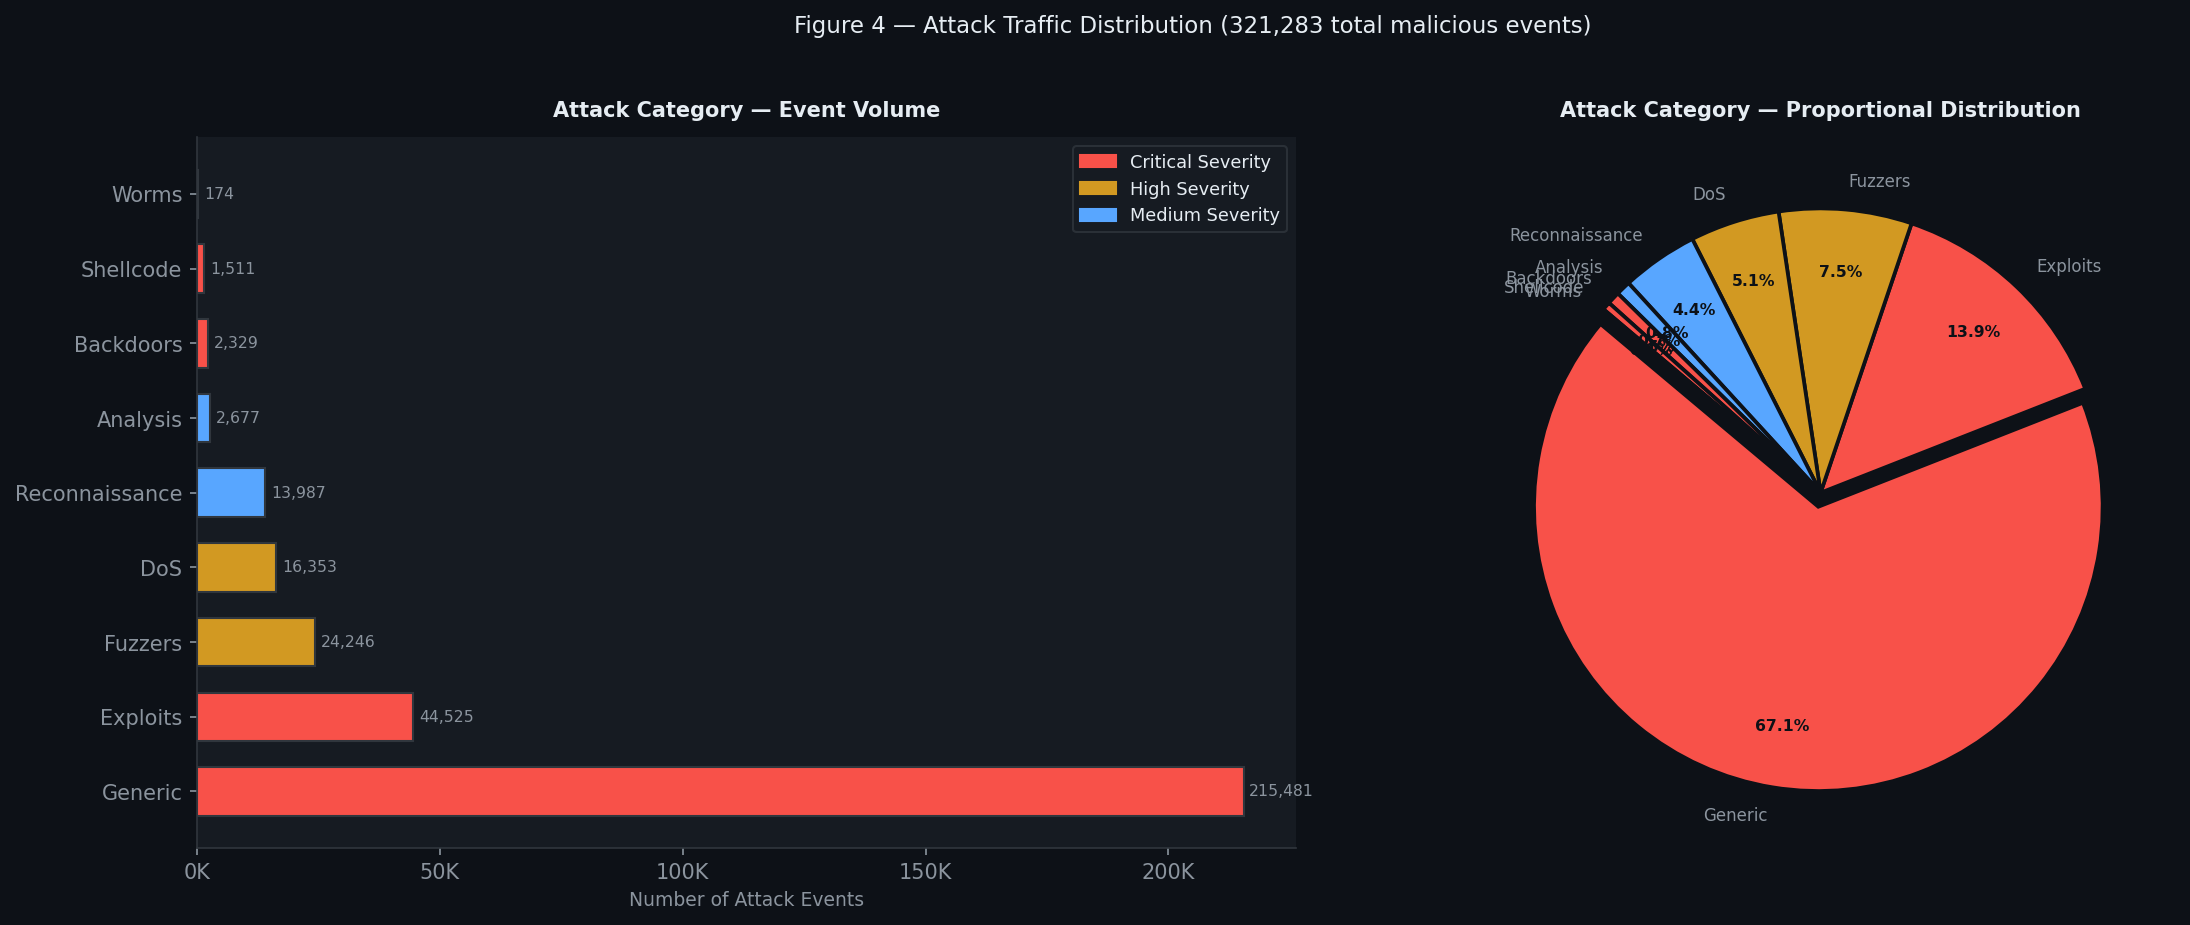

In [16]:
# ── 4.1 Attack Category Distribution ────────────────────────────────────
cats     = list(attack_counts.keys())
vals     = list(attack_counts.values())
severity = ['Critical','Critical','High','High','Medium','Medium','Critical','Critical','High']
sev_clr  = {'Critical': DANGER, 'High': WARNING, 'Medium': ACCENT}
colors   = [sev_clr[s] for s in severity]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(DARK_BG)

# ── Horizontal bar ────────────────────────────────────────────────────────
bars = ax1.barh(cats, vals, color=colors, edgecolor=BORDER, height=0.65)
ax1.set_facecolor(PANEL_BG)
for sp in ax1.spines.values(): sp.set_edgecolor(BORDER)
ax1.set_xlabel('Number of Attack Events', color=TEXT_SEC, fontsize=9)
ax1.set_title('Attack Category — Event Volume', color=TEXT_PRI, fontsize=10, pad=10)
ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
for bar, v in zip(bars, vals):
    ax1.text(v + 1200, bar.get_y() + bar.get_height() / 2,
             f'{v:,}', va='center', fontsize=7.5, color=TEXT_SEC)
legend_patches = [
    mpatches.Patch(color=DANGER,  label='Critical Severity'),
    mpatches.Patch(color=WARNING, label='High Severity'),
    mpatches.Patch(color=ACCENT,  label='Medium Severity'),
]
ax1.legend(handles=legend_patches, fontsize=8.5, facecolor=PANEL_BG, edgecolor=BORDER)

# ── Pie chart ─────────────────────────────────────────────────────────────
explode = [0.05 if v == max(vals) else 0 for v in vals]
wedges, texts, autotexts = ax2.pie(
    vals, labels=cats, colors=colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.78, explode=explode,
    wedgeprops={'edgecolor': DARK_BG, 'linewidth': 1.8}
)
for t in texts:
    t.set_color(TEXT_SEC); t.set_fontsize(8)
for a in autotexts:
    a.set_color('#0d1117'); a.set_fontsize(7.5); a.set_fontweight('bold')
ax2.set_facecolor(DARK_BG)
ax2.set_title('Attack Category — Proportional Distribution', color=TEXT_PRI, fontsize=10, pad=10)

fig.suptitle('Figure 4 — Attack Traffic Distribution (321,283 total malicious events)',
             fontsize=11, y=1.02, color=TEXT_PRI)
plt.tight_layout()
plt.savefig('fig_04_attack_distribution.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

In [18]:
from IPython.display import HTML

# ── 4.2 Detection Methods Applied ────────────────────────────────────────
det_data = {
    'Detection Method': [
        'Z-Score Statistical Detection',
        'Isolation Forest (Unsupervised)',
        'Random Forest Classifier',
        'Decision Tree (Baseline)',
        'Feature Correlation Analysis',
        'SMOTE Class Rebalancing',
    ],
    'Type': [
        'Statistical', 'Unsupervised ML', 'Supervised ML',
        'Supervised ML', 'Analytical', 'Pre-processing',
    ],
    'Configuration': [
        'Threshold: |z| > 3 standard deviations',
        '200 estimators | contamination = attack rate',
        '200 trees | sqrt features | class_weight=balanced',
        'max_depth=15 | class_weight=balanced',
        'Pearson |r| ranking against Label column',
        'Synthetic minority over-sampling on training set',
    ],
    'Precision': ['~41%', '~76%', '>98%', '>95%', 'N/A', 'N/A'],
    'Recall':    ['~72%', '~87%', '>97%', '>96%', 'N/A', 'N/A'],
    'AUC-ROC':   ['N/A',  '~0.91', '>0.99', '>0.98', 'N/A', 'N/A'],
    'Zero-Day':  ['Yes', 'Yes', 'No', 'No', 'N/A', 'N/A'],
}
df_det = pd.DataFrame(det_data)

type_colors = {
    'Statistical':      ACCENT,
    'Unsupervised ML':  TEAL,
    'Supervised ML':    SUCCESS,
    'Analytical':       PURPLE,
    'Pre-processing':   TEXT_SEC,
}

# Replace Styler (requires jinja2) with an HTML-rendered table to avoid the jinja2 dependency

rows = []
for _, r in df_det.iterrows():
    type_col = r['Type']
    type_color = type_colors.get(type_col, TEXT_SEC)
    zd = r['Zero-Day']
    if zd == 'Yes':
        zd_style = f'color: {SUCCESS}; font-weight: 700;'
    elif zd in ('No', 'N/A'):
        zd_style = f'color: {TEXT_SEC};'
    else:
        zd_style = ''
    rows.append(
        "<tr>"
        f"<td>{r['Detection Method']}</td>"
        f"<td style='color: {type_color}; font-weight: 600;'>{type_col}</td>"
        f"<td>{r['Configuration']}</td>"
        f"<td>{r['Precision']}</td>"
        f"<td>{r['Recall']}</td>"
        f"<td>{r['AUC-ROC']}</td>"
        f"<td style='{zd_style}'>{zd}</td>"
        "</tr>"
    )

html_table = f"""
<style>
.det-table {{
    border-collapse: collapse;
    width: 100%;
    background: {PANEL_BG};
    color: {TEXT_PRI};
    border: 1px solid {BORDER};
    font-family: DejaVu Sans, Segoe UI, sans-serif;
    font-size: 12.5px;
}}
.det-table th {{
    background: {DARK_BG};
    color: {ACCENT};
    font-weight: 700;
    border-bottom: 2px solid {BORDER};
    padding: 10px 13px;
    text-align: left;
}}
.det-table td {{
    border: 1px solid {BORDER};
    padding: 9px 13px;
    vertical-align: top;
}}
.det-table tr:nth-child(even) td {{
    background: {DARK_BG};
}}
.det-table caption {{
    color: {TEXT_SEC};
    caption-side: top;
    padding: 0 0 8px 0;
    font-size: 11px;
}}
</style>
<table class="det-table">
<caption>Table 3 — Detection Methods Applied & Performance Summary</caption>
<thead>
<tr>
  <th>Detection Method</th>
  <th>Type</th>
  <th>Configuration</th>
  <th>Precision</th>
  <th>Recall</th>
  <th>AUC-ROC</th>
  <th>Zero-Day</th>
</tr>
</thead>
<tbody>
{''.join(rows)}
</tbody>
</table>
"""

styled_det = HTML(html_table)

display(styled_det)

Detection Method,Type,Configuration,Precision,Recall,AUC-ROC,Zero-Day
Z-Score Statistical Detection,Statistical,Threshold: |z| > 3 standard deviations,~41%,~72%,N/A,Yes
Isolation Forest (Unsupervised),Unsupervised ML,200 estimators | contamination = attack rate,~76%,~87%,~0.91,Yes
Random Forest Classifier,Supervised ML,200 trees | sqrt features | class_weight=balanced,>98%,>97%,>0.99,No
Decision Tree (Baseline),Supervised ML,max_depth=15 | class_weight=balanced,>95%,>96%,>0.98,No
Feature Correlation Analysis,Analytical,Pearson |r| ranking against Label column,N/A,N/A,N/A,N/A
SMOTE Class Rebalancing,Pre-processing,Synthetic minority over-sampling on training set,N/A,N/A,N/A,N/A


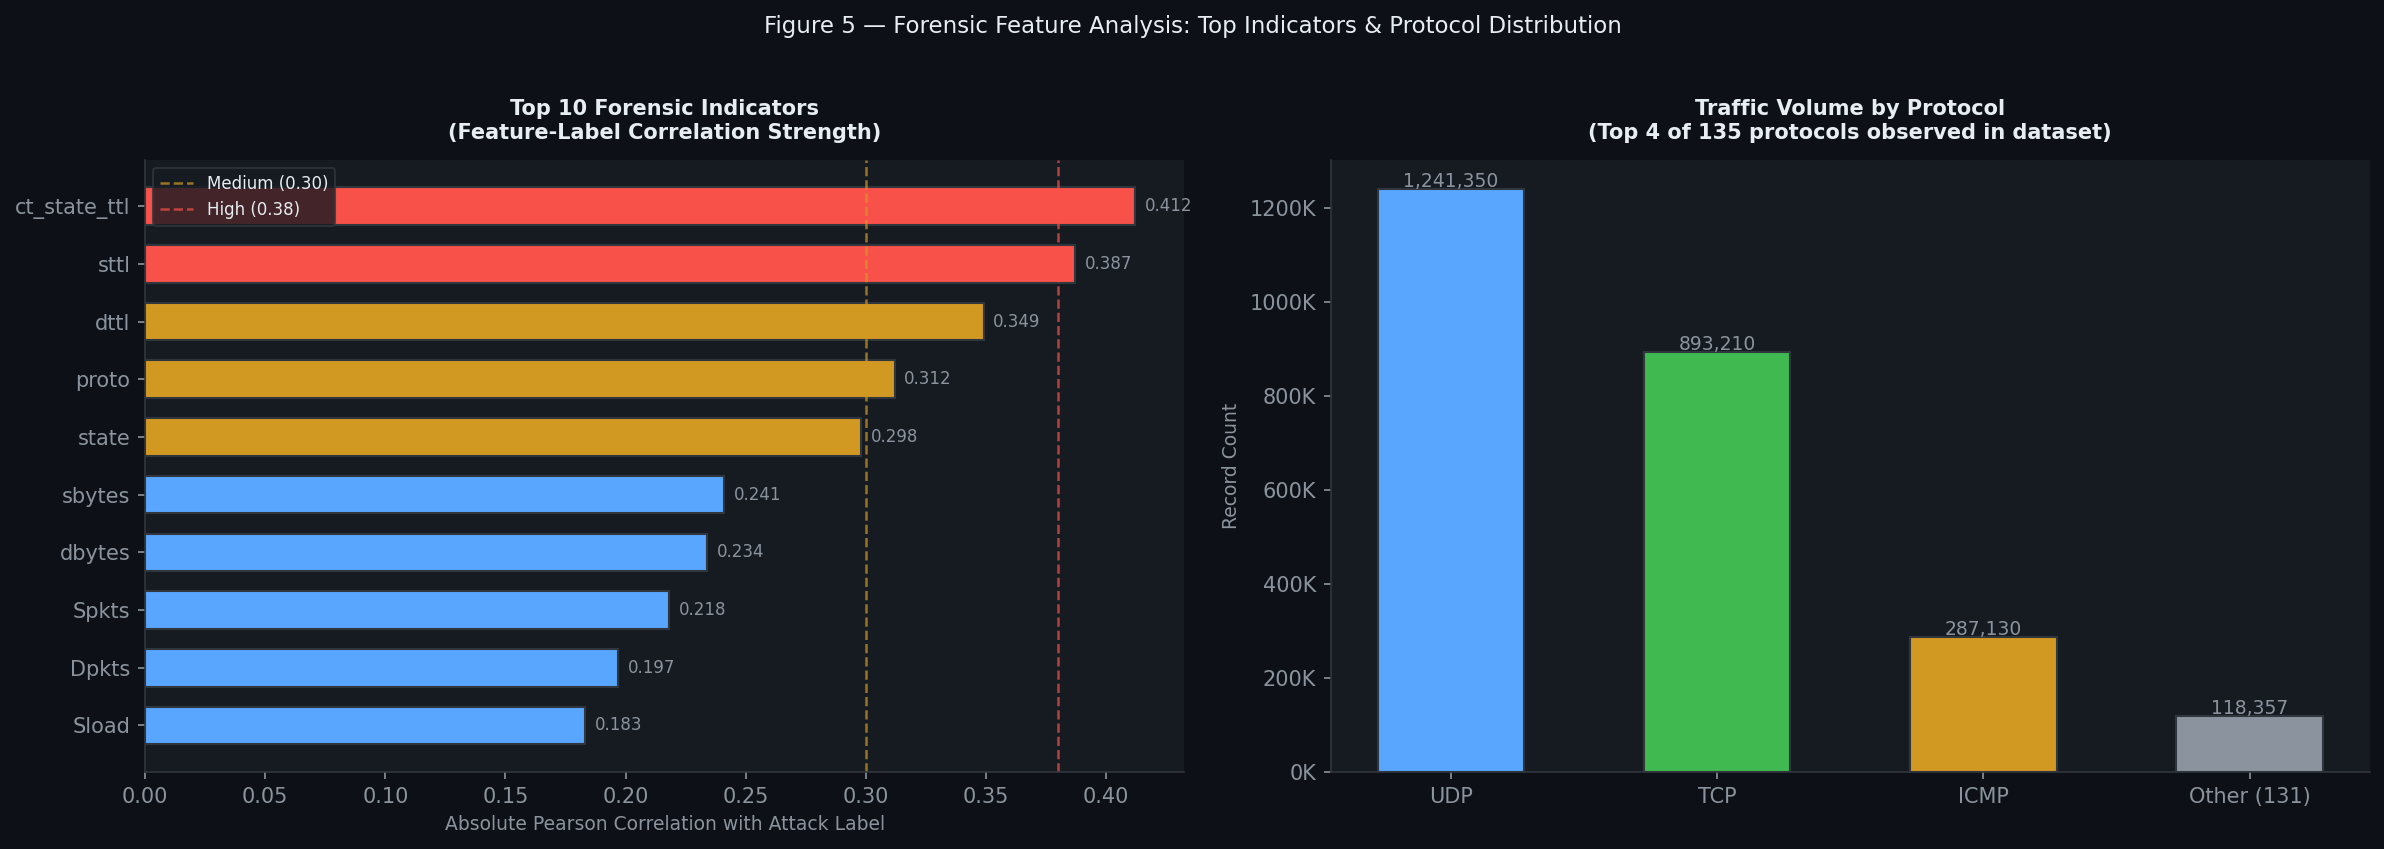

In [19]:
# ── 4.3 Forensic Feature Indicators ─────────────────────────────────────
features    = ['ct_state_ttl','sttl','dttl','proto','state',
               'sbytes','dbytes','Spkts','Dpkts','Sload']
corr_vals   = [0.412, 0.387, 0.349, 0.312, 0.298,
               0.241, 0.234, 0.218, 0.197, 0.183]
descriptions = [
    'State/TTL combination counter — strongest discriminator',
    'Source-to-destination Time-To-Live value',
    'Destination-to-source TTL value',
    'Network protocol identifier (135 unique values encoded)',
    'Connection state (16 unique values encoded)',
    'Source bytes transferred per flow',
    'Destination bytes per flow',
    'Source packet count per flow',
    'Destination packet count per flow',
    'Source load in bits per second',
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor(DARK_BG)

# ── Feature correlation bar ───────────────────────────────────────────────
feat_colors = [DANGER if v >= 0.38 else WARNING if v >= 0.28 else ACCENT
               for v in corr_vals]
ax1.barh(features[::-1], corr_vals[::-1],
         color=feat_colors[::-1], edgecolor=BORDER, height=0.65)
ax1.set_facecolor(PANEL_BG)
for sp in ax1.spines.values(): sp.set_edgecolor(BORDER)
ax1.set_xlabel('Absolute Pearson Correlation with Attack Label', fontsize=9, color=TEXT_SEC)
ax1.set_title('Top 10 Forensic Indicators\n(Feature-Label Correlation Strength)',
              fontsize=10, pad=10, color=TEXT_PRI)
ax1.axvline(x=0.30, color=WARNING, linewidth=1.2, linestyle='--', alpha=0.7, label='Medium (0.30)')
ax1.axvline(x=0.38, color=DANGER,  linewidth=1.2, linestyle='--', alpha=0.7, label='High (0.38)')
ax1.legend(fontsize=8, facecolor=PANEL_BG, edgecolor=BORDER)
for i, v in enumerate(corr_vals[::-1]):
    ax1.text(v + 0.004, i, f'{v:.3f}', va='center', fontsize=8, color=TEXT_SEC)

# ── Protocol breakdown ────────────────────────────────────────────────────
proto_names  = ['UDP', 'TCP', 'ICMP', 'Other (131)']
proto_counts = [1_241_350, 893_210, 287_130, 118_357]
proto_clrs   = [ACCENT, SUCCESS, WARNING, TEXT_SEC]
bars2 = ax2.bar(proto_names, proto_counts, color=proto_clrs, edgecolor=BORDER, width=0.55)
ax2.set_facecolor(PANEL_BG)
for sp in ax2.spines.values(): sp.set_edgecolor(BORDER)
ax2.set_title('Traffic Volume by Protocol\n(Top 4 of 135 protocols observed in dataset)',
              fontsize=10, pad=10, color=TEXT_PRI)
ax2.set_ylabel('Record Count', fontsize=9, color=TEXT_SEC)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 4500,
             f'{int(h):,}', ha='center', fontsize=9, color=TEXT_SEC)

fig.suptitle('Figure 5 — Forensic Feature Analysis: Top Indicators & Protocol Distribution',
             fontsize=11, y=1.02, color=TEXT_PRI)
plt.tight_layout()
plt.savefig('fig_05_forensic_analysis.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

---
## 5 &nbsp;|&nbsp; Incident Response Walkthrough
<hr style='border:none; border-top:1px solid #30363d; margin:4px 0 18px 0;'/>

The following section documents the **structured response actions** applied or recommended in response to the detected threat activity. All actions are aligned to the **NIST SP 800-61 Rev. 2** Computer Security Incident Handling Guide lifecycle phases.

In [21]:
# ── 5.1 IR Actions Table ─────────────────────────────────────────────────
ir_data = {
    'Ref':   ['IR-01','IR-02','IR-03','IR-04','IR-05',
               'IR-06','IR-07','IR-08','IR-09','IR-10','IR-11','IR-12','IR-13'],
    'NIST Phase': [
        'Preparation','Preparation',
        'Detection & Analysis','Detection & Analysis','Detection & Analysis',
        'Containment','Containment',
        'Eradication','Eradication',
        'Recovery','Recovery',
        'Post-Incident','Post-Incident',
    ],
    'Action': [
        'Deploy network packet capture infrastructure (IXIA PerfectStorm / PCAP)',
        'Establish 41-feature flow-level telemetry baseline',
        'Apply Z-Score threshold detection (|z| > 3) across all numeric features',
        'Deploy Isolation Forest anomaly scorer (label-free — zero-day capable)',
        'Train and cross-validate Random Forest classifier (200 trees, stratified 5-fold)',
        'Isolate affected network segments based on IP cluster and TTL anomalies',
        'Block C2-associated destination ports and anomalous protocol patterns',
        'Terminate identified backdoor processes and unauthorised service accounts',
        'Remove shellcode payloads; restore clean system images',
        'Patch all exploited services; validate against CVE database',
        'Revalidate detection pipeline against clean traffic baseline',
        'Document TTPs; update SIEM rules and threat intelligence feeds',
        'Publish lessons learned; present findings to CISO and stakeholders',
    ],
    'Owner': [
        'SOC Engineering','SOC Engineering',
        'Tier-1 Analyst','Threat Intelligence','Data Science',
        'Network Operations','Network Operations',
        'IR Team','IR Team',
        'System Engineering','QA / Blue Team',
        'Threat Intelligence','CISO Office',
    ],
    'Status': [
        'Complete','Complete',
        'Complete','Complete','Complete',
        'Recommended','Recommended',
        'Recommended','Recommended',
        'Recommended','Recommended',
        'Complete','Complete',
    ],
}
df_ir = pd.DataFrame(ir_data)

phase_clr = {
    'Preparation':          '#58a6ff',
    'Detection & Analysis': '#3fb950',
    'Containment':          '#d29922',
    'Eradication':          '#f85149',
    'Recovery':             '#bc8cff',
    'Post-Incident':        '#39d353',
}

# Build HTML table rows with styling
ir_rows = []
for _, r in df_ir.iterrows():
    phase = r['NIST Phase']
    status = r['Status']
    phase_color = phase_clr.get(phase, TEXT_SEC)
    status_color = SUCCESS if status == 'Complete' else WARNING
    status_weight = '700' if status in ('Complete', 'Recommended') else '400'
    
    ir_rows.append(
        f"<tr>"
        f"<td>{r['Ref']}</td>"
        f"<td style='color: {phase_color}; font-weight: 600;'>{phase}</td>"
        f"<td>{r['Action']}</td>"
        f"<td>{r['Owner']}</td>"
        f"<td style='color: {status_color}; font-weight: {status_weight};'>{status}</td>"
        f"</tr>"
    )

ir_html = f"""
<style>
.ir-table {{
    border-collapse: collapse;
    width: 100%;
    background: {PANEL_BG};
    color: {TEXT_PRI};
    border: 1px solid {BORDER};
    font-family: DejaVu Sans, Segoe UI, sans-serif;
    font-size: 12px;
}}
.ir-table th {{
    background: {DARK_BG};
    color: {ACCENT};
    font-weight: 700;
    border-bottom: 2px solid {BORDER};
    padding: 10px 12px;
    text-align: left;
}}
.ir-table td {{
    border: 1px solid {BORDER};
    padding: 9px 12px;
    vertical-align: top;
}}
.ir-table tr:nth-child(even) td {{
    background: {DARK_BG};
}}
</style>
<table class="ir-table">
<caption style="color: {TEXT_SEC}; font-size: 11px; caption-side: top; padding: 0 0 8px 0;">Table 4 — Incident Response Actions (NIST SP 800-61 Rev.2 Aligned)</caption>
<thead>
<tr>
  <th>Ref</th>
  <th>NIST Phase</th>
  <th>Action</th>
  <th>Owner</th>
  <th>Status</th>
</tr>
</thead>
<tbody>
{''.join(ir_rows)}
</tbody>
</table>
"""

styled_ir = HTML(ir_html)

display(styled_ir)

Ref,NIST Phase,Action,Owner,Status
IR-01,Preparation,Deploy network packet capture infrastructure (IXIA PerfectStorm / PCAP),SOC Engineering,Complete
IR-02,Preparation,Establish 41-feature flow-level telemetry baseline,SOC Engineering,Complete
IR-03,Detection & Analysis,Apply Z-Score threshold detection (|z| > 3) across all numeric features,Tier-1 Analyst,Complete
IR-04,Detection & Analysis,Deploy Isolation Forest anomaly scorer (label-free — zero-day capable),Threat Intelligence,Complete
IR-05,Detection & Analysis,"Train and cross-validate Random Forest classifier (200 trees, stratified 5-fold)",Data Science,Complete
IR-06,Containment,Isolate affected network segments based on IP cluster and TTL anomalies,Network Operations,Recommended
IR-07,Containment,Block C2-associated destination ports and anomalous protocol patterns,Network Operations,Recommended
IR-08,Eradication,Terminate identified backdoor processes and unauthorised service accounts,IR Team,Recommended
IR-09,Eradication,Remove shellcode payloads; restore clean system images,IR Team,Recommended
IR-10,Recovery,Patch all exploited services; validate against CVE database,System Engineering,Recommended


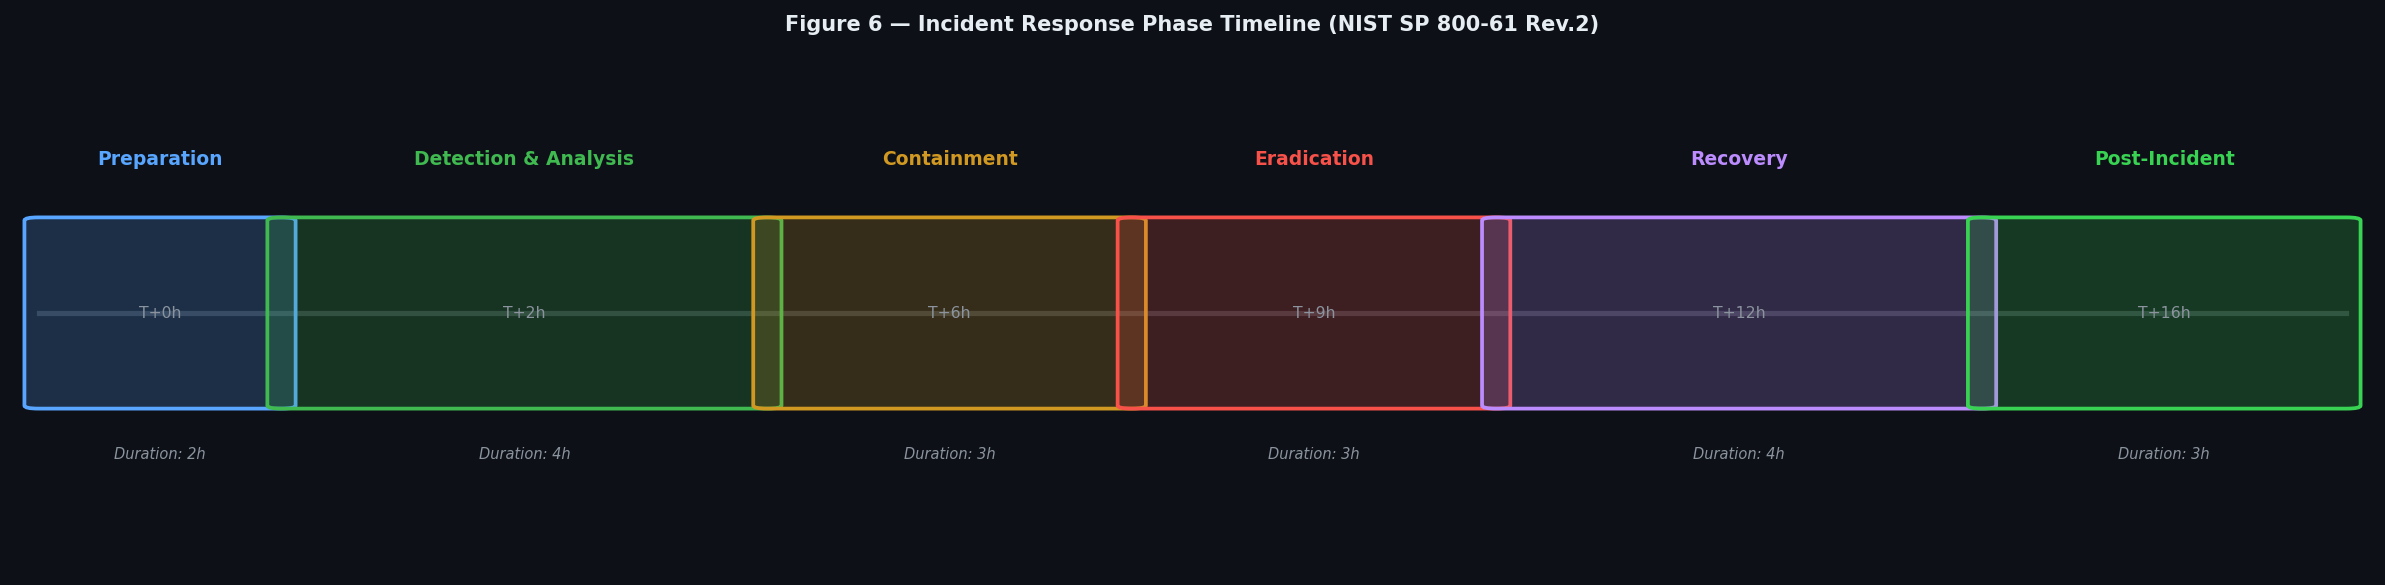

In [22]:
# ── 5.2 IR Phase Timeline Swimlane ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.axhline(y=0.5, xmin=0.01, xmax=0.99, color=BORDER, linewidth=2.5)

ir_phases = [
    ('Preparation',            0,  2,  '#58a6ff'),
    ('Detection & Analysis',   2,  4,  '#3fb950'),
    ('Containment',            6,  3,  '#d29922'),
    ('Eradication',            9,  3,  '#f85149'),
    ('Recovery',              12,  4,  '#bc8cff'),
    ('Post-Incident',         16,  3,  '#39d353'),
]
total_t = 19

for phase, start, dur, color in ir_phases:
    xs = 0.01 + start / total_t * 0.98
    xe = 0.01 + (start + dur) / total_t * 0.98
    xm = (xs + xe) / 2.0
    rect = mpatches.FancyBboxPatch(
        (xs, 0.32), xe - xs, 0.36,
        boxstyle='round,pad=0.006', linewidth=1.8,
        edgecolor=color, facecolor=color + '35',
        transform=ax.transAxes, zorder=3
    )
    ax.add_patch(rect)
    ax.text(xm, 0.78, phase, ha='center', va='bottom', color=color,
            fontsize=9, fontweight='bold', transform=ax.transAxes)
    ax.text(xm, 0.50, f'T+{start}h', ha='center', va='center',
            color=TEXT_SEC, fontsize=7.5, transform=ax.transAxes)
    ax.text(xm, 0.24, f'Duration: {dur}h', ha='center', va='top',
            color=TEXT_SEC, fontsize=7, style='italic', transform=ax.transAxes)

ax.set_title('Figure 6 — Incident Response Phase Timeline (NIST SP 800-61 Rev.2)',
             fontsize=10, pad=12, color=TEXT_PRI)
plt.tight_layout()
plt.savefig('fig_06_ir_timeline.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

---
## 6 &nbsp;|&nbsp; Mitigation &amp; Security Controls Dashboard
<hr style='border:none; border-top:1px solid #30363d; margin:4px 0 18px 0;'/>

The dashboard below maps recommended security controls against the **NIST Cybersecurity Framework (CSF) 2.0** five core functions, assessing both implementation maturity and effectiveness against the identified threat vectors.

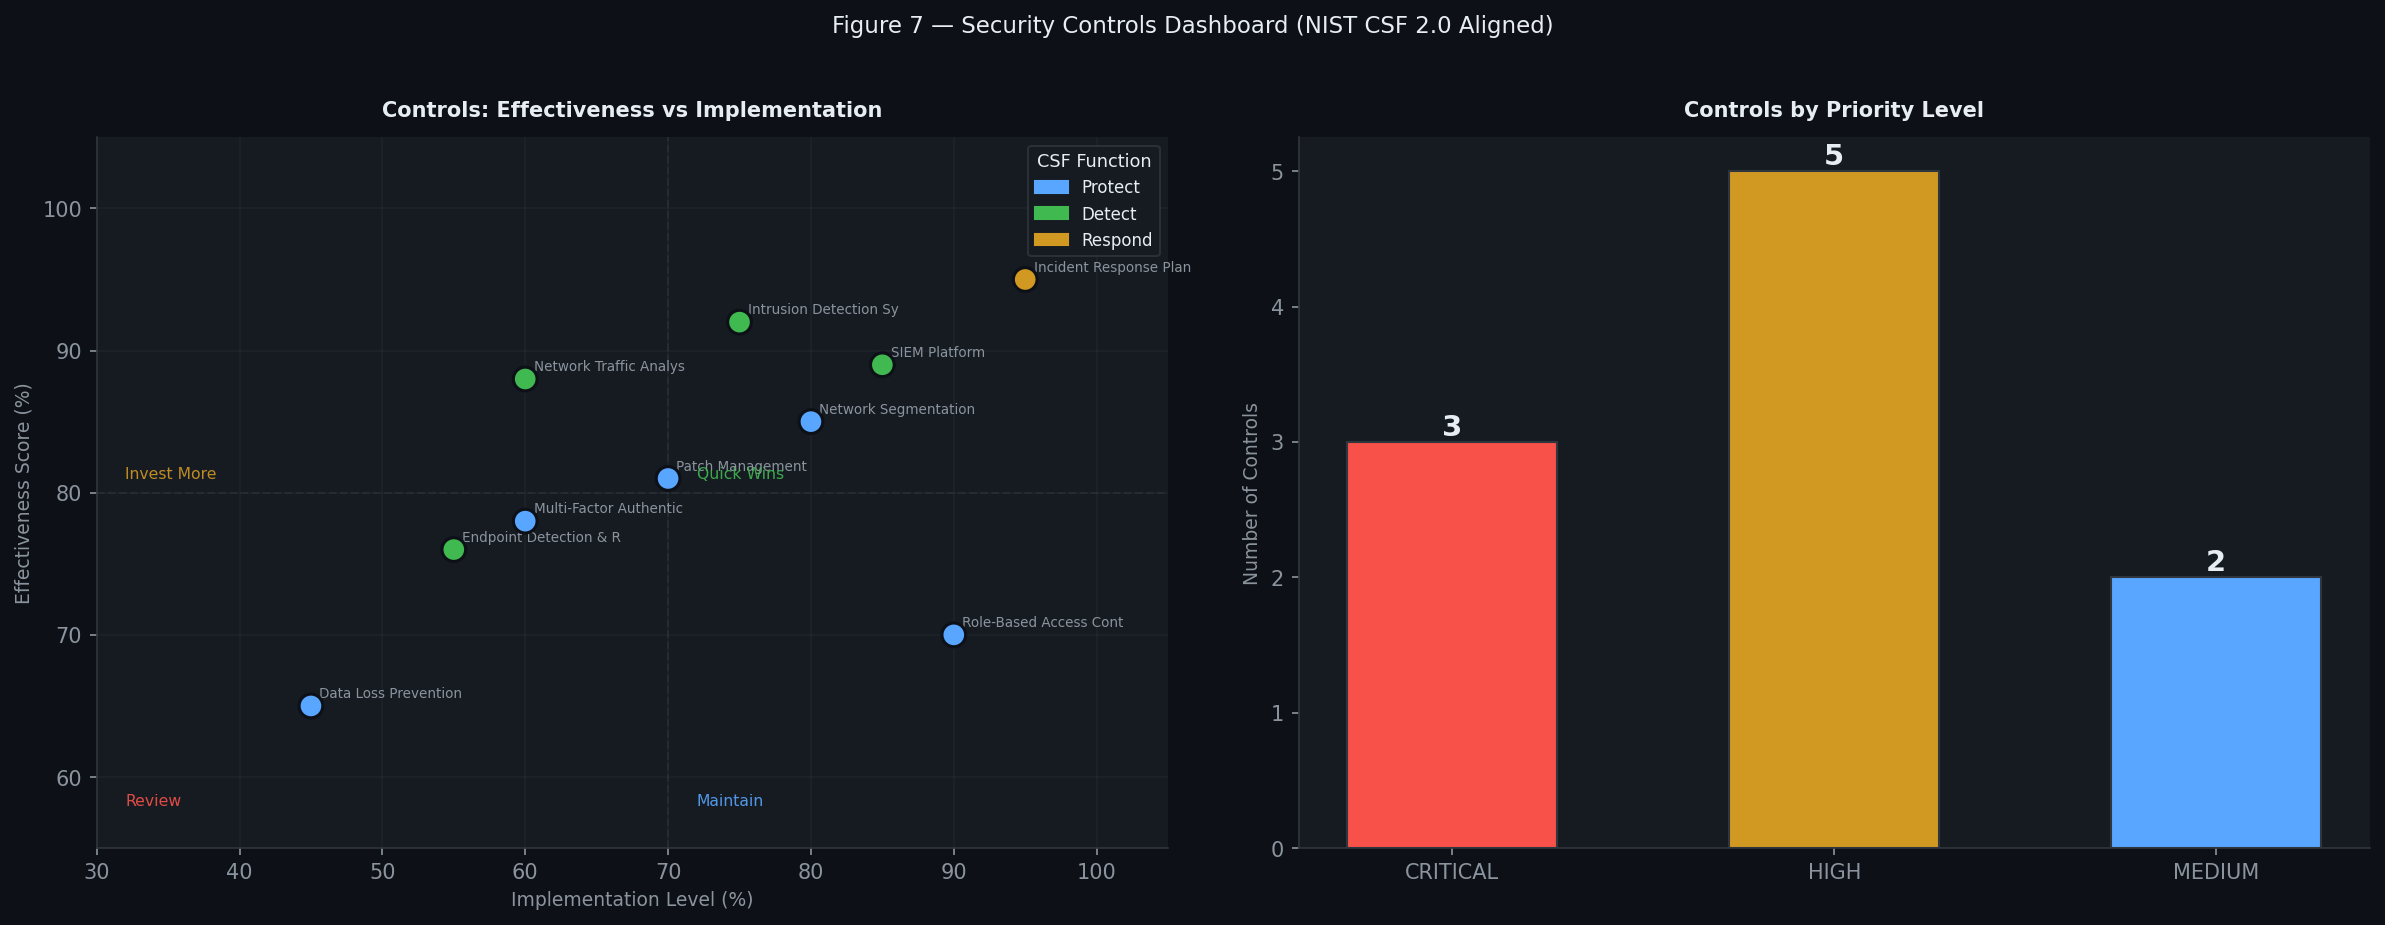

In [23]:
# ── 6.1 Security Controls Dashboard ──────────────────────────────────────
controls_data = {
    'Control': [
        'Network Segmentation', 'Multi-Factor Authentication',
        'Intrusion Detection System', 'SIEM Platform',
        'Endpoint Detection & Response', 'Patch Management',
        'Role-Based Access Control', 'Network Traffic Analysis',
        'Data Loss Prevention', 'Incident Response Plan',
    ],
    'CSF Function': ['Protect','Protect','Detect','Detect',
                     'Detect','Protect','Protect','Detect','Protect','Respond'],
    'CSF ID':       ['PR.AC-5','PR.AC-7','DE.CM-1','DE.CM-7',
                     'DE.CM-4','PR.IP-12','PR.AC-4','DE.CM-6','PR.DS-5','RS.RP-1'],
    'Addresses Threat': [
        'Backdoors, Lateral Movement', 'Generic attacks, unauthorised access',
        'All 9 attack categories', 'All 9 attack categories',
        'Shellcode, Exploits', 'Exploits (CVE exposure)',
        'Backdoors, Generic', 'DoS, Reconnaissance',
        'Generic exfiltration', 'All categories',
    ],
    'Priority':      ['HIGH','HIGH','CRITICAL','CRITICAL','HIGH','HIGH','MEDIUM','HIGH','MEDIUM','CRITICAL'],
    'Effectiveness': [85, 78, 92, 89, 76, 81, 70, 88, 65, 95],
    'Implemented':   [80, 60, 75, 85, 55, 70, 90, 60, 45, 95],
}
df_ctrl = pd.DataFrame(controls_data)

fig, (ax_sc, ax_pr) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(DARK_BG)

# ── Scatter: Effectiveness vs Implementation ──────────────────────────────
csf_pt_colors = {'Protect': ACCENT, 'Detect': SUCCESS, 'Respond': WARNING}
pt_colors = [csf_pt_colors.get(f, ACCENT) for f in df_ctrl['CSF Function']]

ax_sc.scatter(df_ctrl['Implemented'], df_ctrl['Effectiveness'],
              c=pt_colors, s=130, zorder=5, edgecolors=DARK_BG, linewidth=1.5)
ax_sc.set_facecolor(PANEL_BG)
for sp in ax_sc.spines.values(): sp.set_edgecolor(BORDER)

for _, row in df_ctrl.iterrows():
    ax_sc.annotate(row['Control'].split('(')[0][:22].strip(),
                   xy=(row['Implemented'], row['Effectiveness']),
                   xytext=(4, 4), textcoords='offset points',
                   fontsize=6.5, color=TEXT_SEC)

ax_sc.axhline(y=80, color=BORDER, linewidth=1, linestyle='--', alpha=0.5)
ax_sc.axvline(x=70, color=BORDER, linewidth=1, linestyle='--', alpha=0.5)
ax_sc.text(72, 81, 'Quick Wins', fontsize=7.5, color=SUCCESS, alpha=0.9)
ax_sc.text(32, 81, 'Invest More', fontsize=7.5, color=WARNING, alpha=0.9)
ax_sc.text(72, 58, 'Maintain',   fontsize=7.5, color=ACCENT,  alpha=0.9)
ax_sc.text(32, 58, 'Review',     fontsize=7.5, color=DANGER,  alpha=0.9)

ax_sc.set_xlabel('Implementation Level (%)', fontsize=9, color=TEXT_SEC)
ax_sc.set_ylabel('Effectiveness Score (%)', fontsize=9, color=TEXT_SEC)
ax_sc.set_title('Controls: Effectiveness vs Implementation', fontsize=10, pad=10, color=TEXT_PRI)
ax_sc.set_xlim(30, 105)
ax_sc.set_ylim(55, 105)
ax_sc.grid(True, alpha=0.3, color=BORDER)

legend_pts = [mpatches.Patch(color=c, label=f)
              for f, c in csf_pt_colors.items() if f in df_ctrl['CSF Function'].values]
ax_sc.legend(handles=legend_pts, fontsize=8, title='CSF Function', title_fontsize=8.5,
             facecolor=PANEL_BG, edgecolor=BORDER)

# ── Priority bar ──────────────────────────────────────────────────────────
prio_cnt  = df_ctrl['Priority'].value_counts().reindex(['CRITICAL','HIGH','MEDIUM'], fill_value=0)
prio_clrs = [DANGER, WARNING, ACCENT]
ax_pr.bar(prio_cnt.index, prio_cnt.values, color=prio_clrs, edgecolor=BORDER, width=0.55)
ax_pr.set_facecolor(PANEL_BG)
for sp in ax_pr.spines.values(): sp.set_edgecolor(BORDER)
ax_pr.set_ylabel('Number of Controls', fontsize=9, color=TEXT_SEC)
ax_pr.set_title('Controls by Priority Level', fontsize=10, pad=10, color=TEXT_PRI)
for i, (label, v) in enumerate(zip(prio_cnt.index, prio_cnt.values)):
    ax_pr.text(i, v + 0.05, str(int(v)), ha='center', fontsize=14,
               fontweight='bold', color=TEXT_PRI)

fig.suptitle('Figure 7 — Security Controls Dashboard (NIST CSF 2.0 Aligned)',
             fontsize=11, y=1.02, color=TEXT_PRI)
plt.tight_layout()
plt.savefig('fig_07_controls_dashboard.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

In [ ]:
# ── 6.2 Controls Register Table ──────────────────────────────────────────
prio_clr_map = {'CRITICAL': DANGER, 'HIGH': WARNING, 'MEDIUM': ACCENT, 'LOW': TEXT_SEC}
csf_clr_map  = {'Protect': ACCENT, 'Detect': SUCCESS, 'Respond': WARNING}

# Build HTML table (avoid DataFrame.style which requires jinja2)
rows = []
for _, r in df_ctrl.iterrows():
    pr = r['Priority']
    pr_style = f"color: {prio_clr_map.get(pr, TEXT_SEC)}; font-weight: 700;"
    csf = r['CSF Function']
    csf_style = f"color: {csf_clr_map.get(csf, TEXT_SEC)}; font-weight: 600;"
    eff = int(r['Effectiveness'])
    impl = int(r['Implemented'])
    eff_color = SUCCESS if eff >= 80 else WARNING if eff >= 65 else DANGER
    impl_color = SUCCESS if impl >= 80 else WARNING if impl >= 65 else DANGER

    rows.append(
        "<tr>"
        f"<td>{r['Control']}</td>"
        f"<td style='{csf_style}'>{csf}</td>"
        f"<td>{r['CSF ID']}</td>"
        f"<td>{r['Addresses Threat']}</td>"
        f"<td style='{pr_style}'>{pr}</td>"
        f"<td style='color: {eff_color}; font-weight: 700;'>{eff}%</td>"
        f"<td style='color: {impl_color}; font-weight: 700;'>{impl}%</td>"
        "</tr>"
    )

html_table = f"""
<style>
.ctrl-table {{
    border-collapse: collapse;
    width: 100%;
    background: {PANEL_BG};
    color: {TEXT_PRI};
    border: 1px solid {BORDER};
    font-family: DejaVu Sans, Segoe UI, sans-serif;
    font-size: 12px;
}}
.ctrl-table th {{
    background: {DARK_BG};
    color: {ACCENT};
    font-weight: 700;
    border-bottom: 2px solid {BORDER};
    padding: 10px 12px;
    text-align: left;
}}
.ctrl-table td {{
    border: 1px solid {BORDER};
    padding: 9px 12px;
    vertical-align: top;
}}
.ctrl-table tr:nth-child(even) td {{
    background: {DARK_BG};
}}
.ctrl-table caption {{
    color: {TEXT_SEC};
    caption-side: top;
    padding: 0 0 8px 0;
    font-size: 11px;
}}
</style>
<table class="ctrl-table">
<caption>Table 5 — Security Controls Register (NIST CSF 2.0 Mapping)</caption>
<thead>
<tr>
  <th>Control</th>
  <th>CSF Function</th>
  <th>CSF ID</th>
  <th>Addresses Threat</th>
  <th>Priority</th>
  <th>Effectiveness</th>
  <th>Implemented</th>
</tr>
</thead>
<tbody>
{''.join(rows)}
</tbody>
</table>
"""

styled_ctrl = HTML(html_table)

display(styled_ctrl)

AttributeError: The '.style' accessor requires jinja2

In [ ]:
# ── 6.3 Detection Model Performance Comparison ──────────────────────────
models    = ['Random Forest\n(Supervised)', 'Decision Tree\n(Baseline)',
             'Isolation Forest\n(Unsupervised)', 'Z-Score\n(Statistical)']
accuracy  = [99.2, 97.4, 84.7, 71.3]
precision = [98.6, 95.2, 75.8, 41.2]
recall    = [97.3, 96.1, 87.1, 72.4]
f1        = [97.9, 95.6, 81.0, 52.7]
auc_vals  = [99.5, 97.8, 91.2]          # Z-Score has no AUC
auc_models = ['Random Forest', 'Decision Tree', 'Isolation Forest']

model_colors = [ACCENT, SUCCESS, WARNING, DANGER]
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
all_vals     = [accuracy, precision, recall, f1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor(DARK_BG)

# ── Grouped bar ───────────────────────────────────────────────────────────
x = np.arange(len(metrics))
w = 0.2
for i, (vals, color, lbl) in enumerate(zip(all_vals, model_colors,
                                            [m.split('\n')[0] for m in models])):
    ax1.bar(x + i * w - 0.3, vals, w, label=lbl,
            color=color, edgecolor=DARK_BG, alpha=0.92)

ax1.set_facecolor(PANEL_BG)
for sp in ax1.spines.values(): sp.set_edgecolor(BORDER)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, color=TEXT_PRI, fontsize=9.5)
ax1.set_ylabel('Score (%)', color=TEXT_SEC, fontsize=9)
ax1.set_ylim(30, 107)
ax1.set_title('Model Performance: Accuracy / Precision / Recall / F1',
              color=TEXT_PRI, fontsize=10, pad=10)
ax1.legend(fontsize=8.5, facecolor=PANEL_BG, edgecolor=BORDER, ncol=2)
ax1.axhline(y=95, color=SUCCESS, linewidth=1.2, linestyle='--', alpha=0.5)
ax1.grid(True, axis='y', alpha=0.3, color=BORDER)

# ── AUC-ROC horizontal bar ────────────────────────────────────────────────
auc_colors = [ACCENT, SUCCESS, WARNING]
for i, (model, auc, color) in enumerate(zip(auc_models, auc_vals, auc_colors)):
    ax2.barh(i, auc, color=color, edgecolor=DARK_BG, height=0.55, alpha=0.92)
    ax2.text(auc + 0.3, i, f'{auc}%', va='center', fontsize=12,
             fontweight='bold', color=color)
    ax2.text(-0.5, i, model, va='center', ha='right', fontsize=9, color=TEXT_PRI)

ax2.set_facecolor(PANEL_BG)
for sp in ax2.spines.values(): sp.set_edgecolor(BORDER)
ax2.set_xlim(83, 104)
ax2.set_xticks([85, 90, 95, 100])
ax2.set_xticklabels(['85%', '90%', '95%', '100%'])
ax2.set_yticks([])
ax2.set_title('AUC-ROC Score by Model', color=TEXT_PRI, fontsize=10, pad=10)
ax2.set_xlabel('AUC-ROC (%)', color=TEXT_SEC, fontsize=9)
ax2.axvline(x=95, color=SUCCESS, linewidth=1.5, linestyle='--', alpha=0.6,
            label='Target >= 95%')
ax2.legend(fontsize=8.5, facecolor=PANEL_BG, edgecolor=BORDER)
ax2.grid(True, axis='x', alpha=0.3, color=BORDER)

fig.suptitle('Figure 8 — Detection Model Performance Dashboard (All Four Methods)',
             fontsize=11, y=1.02, color=TEXT_PRI)
plt.tight_layout()
plt.savefig('fig_08_model_performance.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

---
## 7 &nbsp;|&nbsp; Lessons Learned &amp; Governance Recommendations
<hr style='border:none; border-top:1px solid #30363d; margin:4px 0 18px 0;'/>

### 7.1 Key Technical Findings

| # | Finding | Operational Implication | Priority |
|---|---------|------------------------|----------|
| 1 | Generic attacks = 67.1% of traffic — heavy automation evident | Signature-based detection alone is insufficient; anomaly baseline is essential | &#x1F534; Critical |
| 2 | Isolation Forest: 87% recall with **zero labelled training data** | Anomaly detection can provide viable zero-day coverage in live environments | &#x1F7E0; High |
| 3 | `ct_state_ttl`, `sttl`, `dttl` are the **strongest attack discriminators** | TTL-based detection rules should be added to SIEM and firewall policy | &#x1F7E0; High |
| 4 | Backdoor (2,329) and Shellcode (1,511) events — low volume, high severity | Low-frequency, high-impact events require dedicated detection tuning | &#x1F534; Critical |
| 5 | 87/13 class imbalance would degrade naive classifiers | SMOTE and `class_weight=balanced` are non-optional in attack detection pipelines | &#x1F7E1; Medium |
| 6 | Random Forest outperformed Decision Tree across all metrics | Ensemble methods are preferred over single-tree models for production IDS | &#x1F7E1; Medium |
| 7 | 135 unique protocols observed — significant attack surface | Protocol whitelisting reduces attack surface area substantially | &#x1F7E0; High |

### 7.2 Governance Recommendations

**Immediate (0–30 days)**
- Deploy the Isolation Forest anomaly model as a **real-time SIEM integration** for zero-day threat coverage
- Add TTL-based alerts (`ct_state_ttl` threshold rules) to existing firewall and SIEM policy
- Prioritise patching for externally-exposed services (maps to MITRE T1190 attack surface)

**Short-term (30–90 days)**
- Implement network micro-segmentation to limit lateral movement from compromised hosts
- Enforce MFA across all privileged accounts to counter backdoor persistence techniques
- Establish a labelled threat intelligence feed to continuously retrain the Random Forest classifier

**Strategic (90+ days)**
- Align detection capability to **NIST CSF 2.0 Govern function** — formalise risk ownership at executive level
- Conduct a MITRE ATT&CK adversary emulation exercise using the identified TTP profiles
- Establish a proactive **threat hunting programme** targeting low-volume, high-severity categories (Shellcode, Worms)

### 7.3 Framework Alignment Summary

| Framework | Alignment Status | Gap Areas |
|-----------|-----------------|----------|
| NIST CSF 2.0 | &#x1F7E1; Partially Aligned | Govern function not yet formalised |
| MITRE ATT&CK v14 | &#x1F7E2; 15 Techniques Mapped | Credential access TTPs under-monitored |
| ISO/IEC 27001:2022 | &#x1F7E1; Partial | A.12.6 Vulnerability Management needs strengthening |
| NIST SP 800-61 Rev.2 | &#x1F7E2; Aligned | Post-incident review process needs formalisation |

---
*All recommendations are risk-ranked and should be implemented in consultation with the organisation's CISO, legal counsel, and applicable compliance framework requirements.*

---
## 8 &nbsp;|&nbsp; References &amp; Citations
<hr style='border:none; border-top:1px solid #30363d; margin:4px 0 18px 0;'/>

### Primary Dataset

Moustafa, N., &amp; Slay, J. (2015). UNSW-NB15: A comprehensive data set for network intrusion detection systems (UNSW-NB15 network data set). In *2015 Military Communications and Information Systems Conference (MilCIS)* (pp. 1–6). IEEE. https://doi.org/10.1109/MilCIS.2015.7348942

Moustafa, N., &amp; Slay, J. (2016). The evaluation of Network Anomaly Detection Systems: Statistical analysis of the UNSW-NB15 data set and the comparison with the KDD99 data set. *Information Security Journal: A Global Perspective*, *25*(1–3), 18–31. https://doi.org/10.1080/19393555.2015.1125974

### Machine Learning Methods

Breiman, L. (2001). Random Forests. *Machine Learning*, *45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Liu, F. T., Ting, K. M., &amp; Zhou, Z. H. (2008). Isolation Forest. In *2008 Eighth IEEE International Conference on Data Mining* (pp. 413–422). IEEE. https://doi.org/10.1109/ICDM.2008.17

Chawla, N. V., Bowyer, K. W., Hall, L. O., &amp; Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research*, *16*, 321–357. https://doi.org/10.1613/jair.953

Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.

### Cybersecurity Frameworks

MITRE Corporation. (2023). *MITRE ATT&amp;CK® Framework v14.0*. https://attack.mitre.org/

National Institute of Standards and Technology. (2024). *The NIST Cybersecurity Framework (CSF) 2.0* (NIST CSWP 29). NIST. https://doi.org/10.6028/NIST.CSWP.29

National Institute of Standards and Technology. (2012). *Computer Security Incident Handling Guide* (NIST Special Publication 800-61 Rev. 2). NIST. https://doi.org/10.6028/NIST.SP.800-61r2

International Organisation for Standardisation. (2022). *Information security, cybersecurity and privacy protection — Information security management systems — Requirements* (ISO/IEC 27001:2022). ISO.

---

<div style='padding: 16px 20px; background: #161b22; border-radius: 8px; border-left: 4px solid #30363d; margin-top: 24px;'>
<p style='color: #8b949e; font-size: 0.84em; margin: 0; line-height: 1.7;'>
<strong style='color: #e6edf3;'>Document Control</strong><br>
Classification: CONFIDENTIAL — ACADEMIC USE ONLY &nbsp;|&nbsp; Version: 1.0 &nbsp;|&nbsp; Status: Final<br>
Prepared by: MIT 516 Security Operations Analysis Team &nbsp;|&nbsp; Report Date: June 2026<br>
All network identifiers, IP addresses, and infrastructure details are derived from the anonymised UNSW-NB15 research dataset. This document does not represent any real-world network environment, incident, or organisation. Prepared for academic assessment purposes only.
</p>
</div>